In [ ]:
from google.colab import files
uploaded = files.upload()

Saving collegiate_athlete_injury_dataset.csv to collegiate_athlete_injury_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0


In [ ]:
# Drop ID
if 'Athlete_ID' in df.columns:
    df = df.drop('Athlete_ID', axis=1)

# Encode categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(['Performance_Score', 'Injury_Indicator'], axis=1)
y = df['Injury_Indicator']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

# Input layer (recommended way)
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.1328 - loss: 0.9932 - val_accuracy: 0.2500 - val_loss: 0.9910
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1484 - loss: 0.9498 - val_accuracy: 0.2812 - val_loss: 0.9526
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1719 - loss: 0.9124 - val_accuracy: 0.3125 - val_loss: 0.9170
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2109 - loss: 0.8761 - val_accuracy: 0.3125 - val_loss: 0.8837
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2422 - loss: 0.8451 - val_accuracy: 0.3438 - val_loss: 0.8529
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2891 - loss: 0.8153 - val_accuracy: 0.3750 - val_loss: 0.8244
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 0.7895 - val_accuracy: 0.4688 - val_loss: 0.7971
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4141 - loss: 0.7646 - val_accuracy: 0.5312 - val_loss: 0.7722


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8250 - loss: 0.5523 
Accuracy: 0.824999988079071


In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90        37
           1       0.00      0.00      0.00         3

    accuracy                           0.82        40
   macro avg       0.46      0.45      0.45        40
weighted avg       0.85      0.82      0.84        40



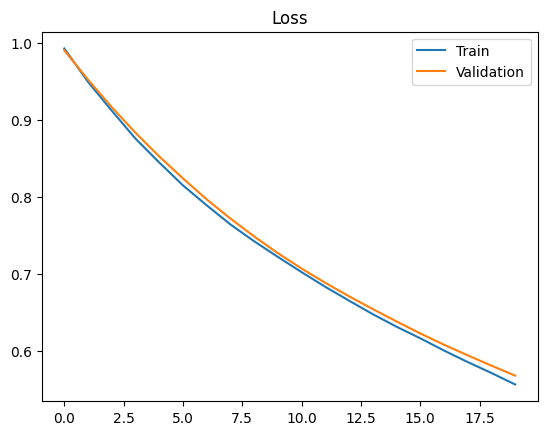

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss")
plt.show()

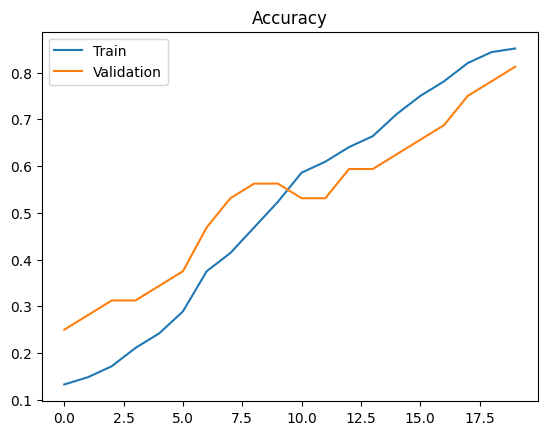

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()